In [1]:
#图标以及程序正确版 不改动
import sys
import subprocess
import importlib

def _pip_install(pkg: str) -> None:
    """Install a package via pip."""
    print(f"Installing {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    print(f"Installed {pkg}.")

def ensure_import(import_name: str, pip_name: str | None = None):
    """
    Ensure a module can be imported.
    - import_name: name used in `import ...`
    - pip_name: name used in `pip install ...` (defaults to import_name)
    Returns the imported module object.
    """
    if pip_name is None:
        pip_name = import_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        _pip_install(pip_name)
        return importlib.import_module(import_name)

# ----------------- Imports -----------------

import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# FiPy
fipy = ensure_import("fipy", "fipy")
from fipy import *  # keep your original usage style

# tqdm (Notebook flavor). If notebook submodule is missing, fallback to plain tqdm.
try:
    from tqdm.notebook import tqdm
except Exception:
    tqdm_mod = ensure_import("tqdm", "tqdm")
    from tqdm import tqdm

# SciPy: save/load .mat
scipy = ensure_import("scipy", "scipy")
from scipy.io import savemat, loadmat

# Notebook-only: matplotlib inline (safe)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("All packages are ready!")

All packages are ready!


In [2]:
d1  = 1      # diffusion coefficient for Laplacian  (d_1)
d2  = 3 # -2       # coefficient in the non-local flux     (d_2)
r1  = 0.1           # logistic reaction factor             (f(u)=r1*u*(1-u))
tau =2#delay length
epsilon = 1.5
z= np.pi         # domain length
L=1*z
n_init = 2        # k in main_hopf2
u_bar = 1

# grid settings
Nx = 101
dt = 0.05
Tend =300# tital simulation time

# plot
update_step = 200
# save
mat_filename = 'result'

In [3]:
steps = int(round(Tend/dt))

# grid def and initialize
mesh = Grid1D(nx=Nx, Lx=L) 

# u: 当前时刻的解 (待求变量)
u = CellVariable(name="u", mesh=mesh, value=0., hasOld=True)

# u_tau: 历史积分后的场 (作为已知系数)
u_tau = CellVariable(name="u_tau", mesh=mesh, value=0.)

# 初始化 u (高斯分布)
x = mesh.cellCenters[0]
#u.setValue(u_bar + 0.02 * np.cos(n_init*np.pi*x / L))
u.setValue(0.8 + 0.01 * np.cos(n_init*np.pi*x / L))
u.updateOld()

# 可视化初始条件
plt.plot(x, u)
plt.title("u0")

Text(0.5, 1.0, 'u0')

In [4]:
# === 3. 历史数据管理 (环形缓冲区) ===
# 计算需要存储多少步历史
history_steps = int(np.round(tau / dt)) + 1
if history_steps % 2 == 0: history_steps += 1

# 初始化历史 buffer (存储 numpy 数组而不是 FiPy 变量，节省内存)
# 假设过去一直是初始状态
u_history = deque([u.value.copy() for _ in range(history_steps)], maxlen=history_steps)

# 预计算权重 h(s)（按图片中的分段形式）
s_vec = np.linspace(-tau, 0, history_steps)
h_weights = np.zeros(history_steps)

for i, s in enumerate(s_vec):
    if -tau <= s <= -epsilon:
        h_weights[i] = 2.0 / (tau * (tau - epsilon)) * (s + tau)
    elif -epsilon <= s <= 0:
        h_weights[i] = -2.0 / (tau * epsilon) * s
    else:
        h_weights[i] = 0.0

ds = s_vec[1] - s_vec[0]
h_weights = h_weights * ds

# 可视化权重
plt.plot(s_vec, h_weights)
print(f"sum of h_win= {np.sum(h_weights)}")

sum of h_win= 1.0000000000000009


In [5]:

# 对流项采用迎风格式 d_2 \nabla \cdot ( u \nabla  u_\tau)
velocity = d2 * u_tau.faceGrad
advection = UpwindConvectionTerm(coeff=velocity, var=u)
# 反应项，部分隐式法 reaction = r1 * u * (1-u)
reaction_explicit = r1 * u
reaction_implicit = ImplicitSourceTerm(coeff=-r1*u, var=u)
reaction = reaction_explicit + reaction_implicit
# PDE, 隐式方法
eq = (TransientTerm(var=u) == DiffusionTerm(coeff=d1, var=u) + advection + reaction)

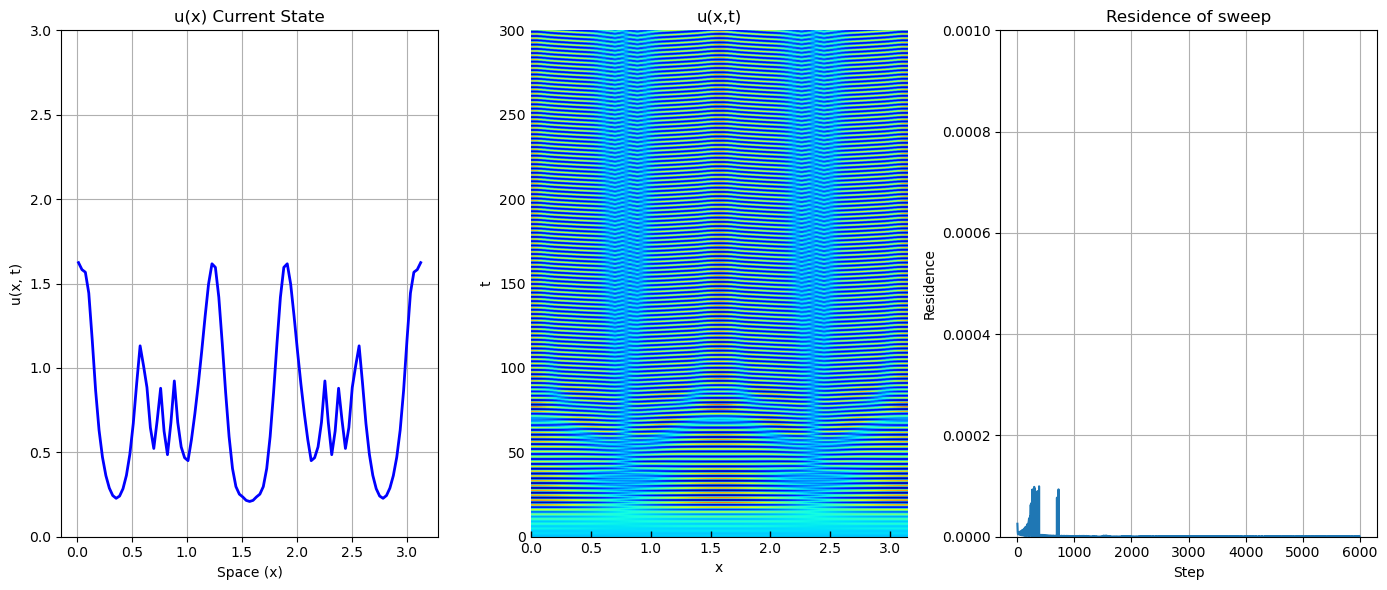

  0%|          | 0/6000 [00:00<?, ?it/s]

In [6]:
# === 5. 仿真循环 ===

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))
# [上图] 实时波形
line, = ax1.plot(x, u.value, 'b-', linewidth=2)
ax1.set_ylim(0, 3)
ax1.set_ylabel('u(x, t)')
ax1.set_xlabel('Space (x)')
ax1.set_title('u(x) Current State')
ax1.grid(True)

# [下图] (X, t) 热力图容器
# 我们预先分配一个全 0 的矩阵来存储所有结果
# 矩阵形状: [时间步数, 空间点数]
solution_matrix = np.zeros((steps, Nx))
solution_matrix[0, :] = u.value # 存入初始状态
# 初始化热力图对象 (类似于 imagesc 或 surf view 2)
# extent 参数用于设置坐标轴的真实物理范围 [x_min, x_max, t_max, t_min]
#heatmap = ax2.imshow(solution_matrix, aspect='auto', cmap='jet', vmin=0, vmax=2.5,
                    # extent=[0, L, steps*dt, 0])
                     # 注意：extent 的 t 顺序可能需要根据习惯调整，这里设为 0 在上
heatmap = ax2.imshow(
    solution_matrix,
    aspect='auto',
    cmap='jet',
    vmin=0, vmax=2.5,
    extent=[0, L, 0, steps*dt],
    origin='lower'
)


ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_title('u(x,t)')
#plt.colorbar(heatmap, ax=ax2, label='Concentration u')

# ax3 绘制 残差图
residences = np.zeros((steps,))
resid_line, = ax3.plot(range(steps), residences)
ax3.set_ylim(0, 1e-3)
ax3.set_ylabel("Residence")
ax3.set_xlabel('Step')
ax3.set_title('Residence of sweep')
ax3.grid(True)

plt.tight_layout()

obs_display = display(fig, display_id=True)
plt.close(fig)

pbar = tqdm(range(steps))

for step in pbar:
    # --- A. 计算 u_tau (积分) ---
    # 将 deque 转为矩阵计算: (history_steps, nx)
    history_matrix = np.array(u_history)
    # 点积: (1, history_steps) * (history_steps, nx) -> (1, nx)
    u_tau_val = np.dot(h_weights, history_matrix)

    # 更新 FiPy 变量 u_tau 的值
    u_tau.setValue(u_tau_val)

    # 注意：advection_velocity 依赖 u_tau
    # FiPy 的惰性求值会自动更新 advection_velocity，
    # 但为了保险，有时需要显式更新系数（视版本而定，通常自动更新）

    # --- B. 求解 PDE ---
    # sweep() 用于非线性方程迭代，solve() 用于线性
    # 因为对流速度是"已知"的(基于u_tau)，且源项简单，solve 也可以
    resid = 1e6
    cnt = 0
    last_resid = resid
    while resid > 1e-4:
        resid = eq.sweep(var=u, dt=dt)
        cnt += 1
        if cnt % 100 == 0:
            pass # print(f'{cnt=}, {resid=}')
        if abs(resid - last_resid) < 1e-5:
            # print(f"{resid=}, break")
            break
        last_resid = resid

    

    # --- C. 更新历史 ---
    u_history.append(u.value.copy()) # 自动挤出最旧的数据
    solution_matrix[step, :] = u.value
    residences[step] = resid
    # ---
    u.updateOld()
    pbar.set_postfix({'Resid': f'{resid:2e}'})


# ===== 热图初始化（稳定版）=====与fenbuv不同
if step % update_step == 0 or step == steps - 1:
    line.set_ydata(u.value)

    # 更新热图像素
    heatmap.set_data(solution_matrix)

    # --- 强制锁死坐标范围（防止被 autoscale 改回去）---
    heatmap.set_extent([0, L, 0, steps*dt])   # 绑定真实坐标（非常关键）
    ax2.set_xlim(0, L)
    ax2.set_ylim(0, steps*dt)
    ax2.autoscale(False)                      # 等价于同时关掉 x/y autoscale，更稳
    # 刻度风格
    ax2.tick_params(direction='in', length=4, width=1)
    # --- 强制去掉边框线（上/右/左）---
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    # y 轴：不要刻度尺
    ax2.tick_params(axis='y', length=0)   # 👈 没有刻度线
    resid_line.set_ydata(residences)
    obs_display.update(fig)
#if resid is None:
#            break
# =========================
# 保存 ax2 单独图片
# =========================

fig.canvas.draw()

bbox = ax2.get_tightbbox(fig.canvas.get_renderer())
bbox = bbox.transformed(fig.dpi_scale_trans.inverted())
fig.savefig("ax2_heatmap.eps", bbox_inches=bbox, format="eps")
#fig.savefig("ax2_heatmap.pdf", bbox_inches=bbox, format="pdf")
#fig.savefig("ax2_heatmap.png", bbox_inches=bbox, dpi=300)
# 去边框（论文级风格）
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

plt.close()

In [7]:
bw = 0.01
fig, ax2 = plt.subplots(1, 1, figsize=(6, 6))
#heatmap = ax2.imshow(solution_matrix, aspect='auto', cmap='jet', vmin=1-bw, vmax=1+bw,
                  #   extent=[0, L, 0, steps*dt],  origin='lower' )
                     # 注意：extent 的 t 顺序可能需要根据习惯调整，这里设为 0 在上
heatmap = ax2.imshow(
    solution_matrix,
    aspect='auto',
    cmap='jet',
    vmin=0, vmax=2.5,
    extent=[0, L, 0, steps*dt],
    origin='lower'
)


ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_title('u(x,t)')
plt.colorbar(heatmap, ax=ax2, label='Concentration u')